In [1]:
import sys;sys.path.append('../..')
from abslithist import *

In [2]:
df_fic_meta = pd.read_excel('/Users/ryan/lltk_data/corpora/canon_fiction/metadata.xls').set_index('id')
df_poe_meta = pd.read_csv('/Users/ryan/lltk_data/corpora/chadwyck_poetry/metadata.csv').set_index('id')

In [106]:
df_fic = pd.read_pickle(os.path.join(PATH_DATA,'scores','bak','data.scores.CanonFiction.pkl')).dropna()
df_poe = pd.read_pickle(os.path.join(PATH_DATA,'scores','bak','data.scores.ChadwyckPoetry.pkl')).dropna()

df_fic = df_fic.join(df_fic_meta[['year']])
df_poe = df_poe.join(df_poe_meta[['year']])

df_fic['genre'] = 'Fiction'
df_poe['genre'] = 'Verse'

In [108]:
df_essay = pd.read_pickle(os.path.join(PATH_DATA,'scores','v3','data.scores.HathiEssays.pkl'))
df_essay['genre'] = 'Essay'
df_essay['Abs-Conc.Median.median'] = df_essay['score']

In [60]:
df_bpo = pd.read_pickle(os.path.join(PATH_DATA,'scores','bak','data.scores.BPO.pkl'))
df_bpo['genre'] = [x.split('/')[1] for x in df_bpo.index]
df_bpo['year'] = [int(x.split('/')[0]) for x in df_bpo.index]
df_bpo.genre.value_counts()

genre
Unknown                7518
General_Information    6747
Review                 6156
Back_Matter            5166
Poem                   4968
Correspondence         4431
Front_Matter           4126
Advertisement          3565
Fiction                3388
News                   2368
Obituary               1495
Recipe                  366
Undefined               155
Name: count, dtype: int64

In [109]:
bpo_genres = ['Review', 'Correspondence', 'News', 'Unknown', 'General_Information']

In [111]:
df = pd.concat([
    df_bpo[df_bpo.genre.isin(bpo_genres)].assign(genre='Periodical'),
    df_fic, 
    df_poe,
    df_essay
])
df=df.dropna(subset=['year'])
df['decade'] = df.year.astype(int) // 10 * 10


In [112]:
p9.options.figure_size = (12,6)
p9.options.dpi = 300
df.genre.value_counts()

genre
Verse         306039
Periodical     27220
Essay           6932
Fiction         1805
Name: count, dtype: int64

In [113]:
# fig = (
#     p9.ggplot(
#         df,
#         p9.aes(x='year', y='Abs-Conc.Median.median', color='genre')
#     )
#     # + p9.geom_point()
#     + p9.geom_smooth(method='loess')
#     + p9.theme_minimal()
# )
# fig

In [114]:
yearcol = 'year'
odf = get_avgs_df(df, gby=["genre", yearcol], y="Abs-Conc.Median.median")
# odf = odf.query('count >= 5')
odf

mean    stderr  count
genre year                             
Essay 1666.0 -0.234430       NaN      1
      1673.0 -0.928705       NaN      1
      1694.0 -1.022314       NaN      1
      1701.0 -0.986560       NaN      1
      1720.0 -0.773601  0.004123      2
...                ...       ...    ...
Verse 2000.0  0.867079  0.031796     64
      2001.0  0.022012  0.029628    294
      2002.0  0.345992  0.054673     40
      2003.0  0.604908  0.058602     77
      2004.0  0.908110  0.067923     26

[1382 rows x 3 columns]

In [130]:
def plot_avgs_df(figdf, **labs):
    fig = (
        p9.ggplot(
            figdf,
            p9.aes(x=yearcol, y='mean', linetype='genre', shape='genre',color='genre'),
        )
        # + p9.geom_errorbar(p9.aes(ymin='mean-stderr', ymax='mean+stderr'), width=10, alpha=0.75)
        # + p9.geom_point()
        # + p9.geom_line()
        + p9.geom_point(p9.aes(y='mean',size='count'), alpha=.5)
        # + p9.facet_wrap('genre', scales='free_y')
        + p9.theme_minimal()
        + p9.scale_size_continuous(range=(.5, 5))
        + p9.geom_smooth(method='loess', span=0.3, alpha=0.15, size=1)
        + p9.labs(**labs)
        + p9.theme(figure_size=(12,6), dpi=300)
        + p9.scale_y_continuous(limits=(-4,4))
        # + p9.scale_linetype_manual(values=['solid', 'dashed', 'dotted', 'dotdash', 'longdash', 'twodash'])
        # + p9.scale_y_continuous(limits=(-2,2))
    )
    return fig


In [131]:
# genres = {'Essay','Fiction', 'Verse', 'Treatise', 'Sermon', 'Periodical'}
# # genres = {'Essay','Fiction', 'Verse'}
# genres = {'Essay','Fiction', 'Verse'}
# genres = {'Essay', 'Sermon','Fiction', 'Verse'}

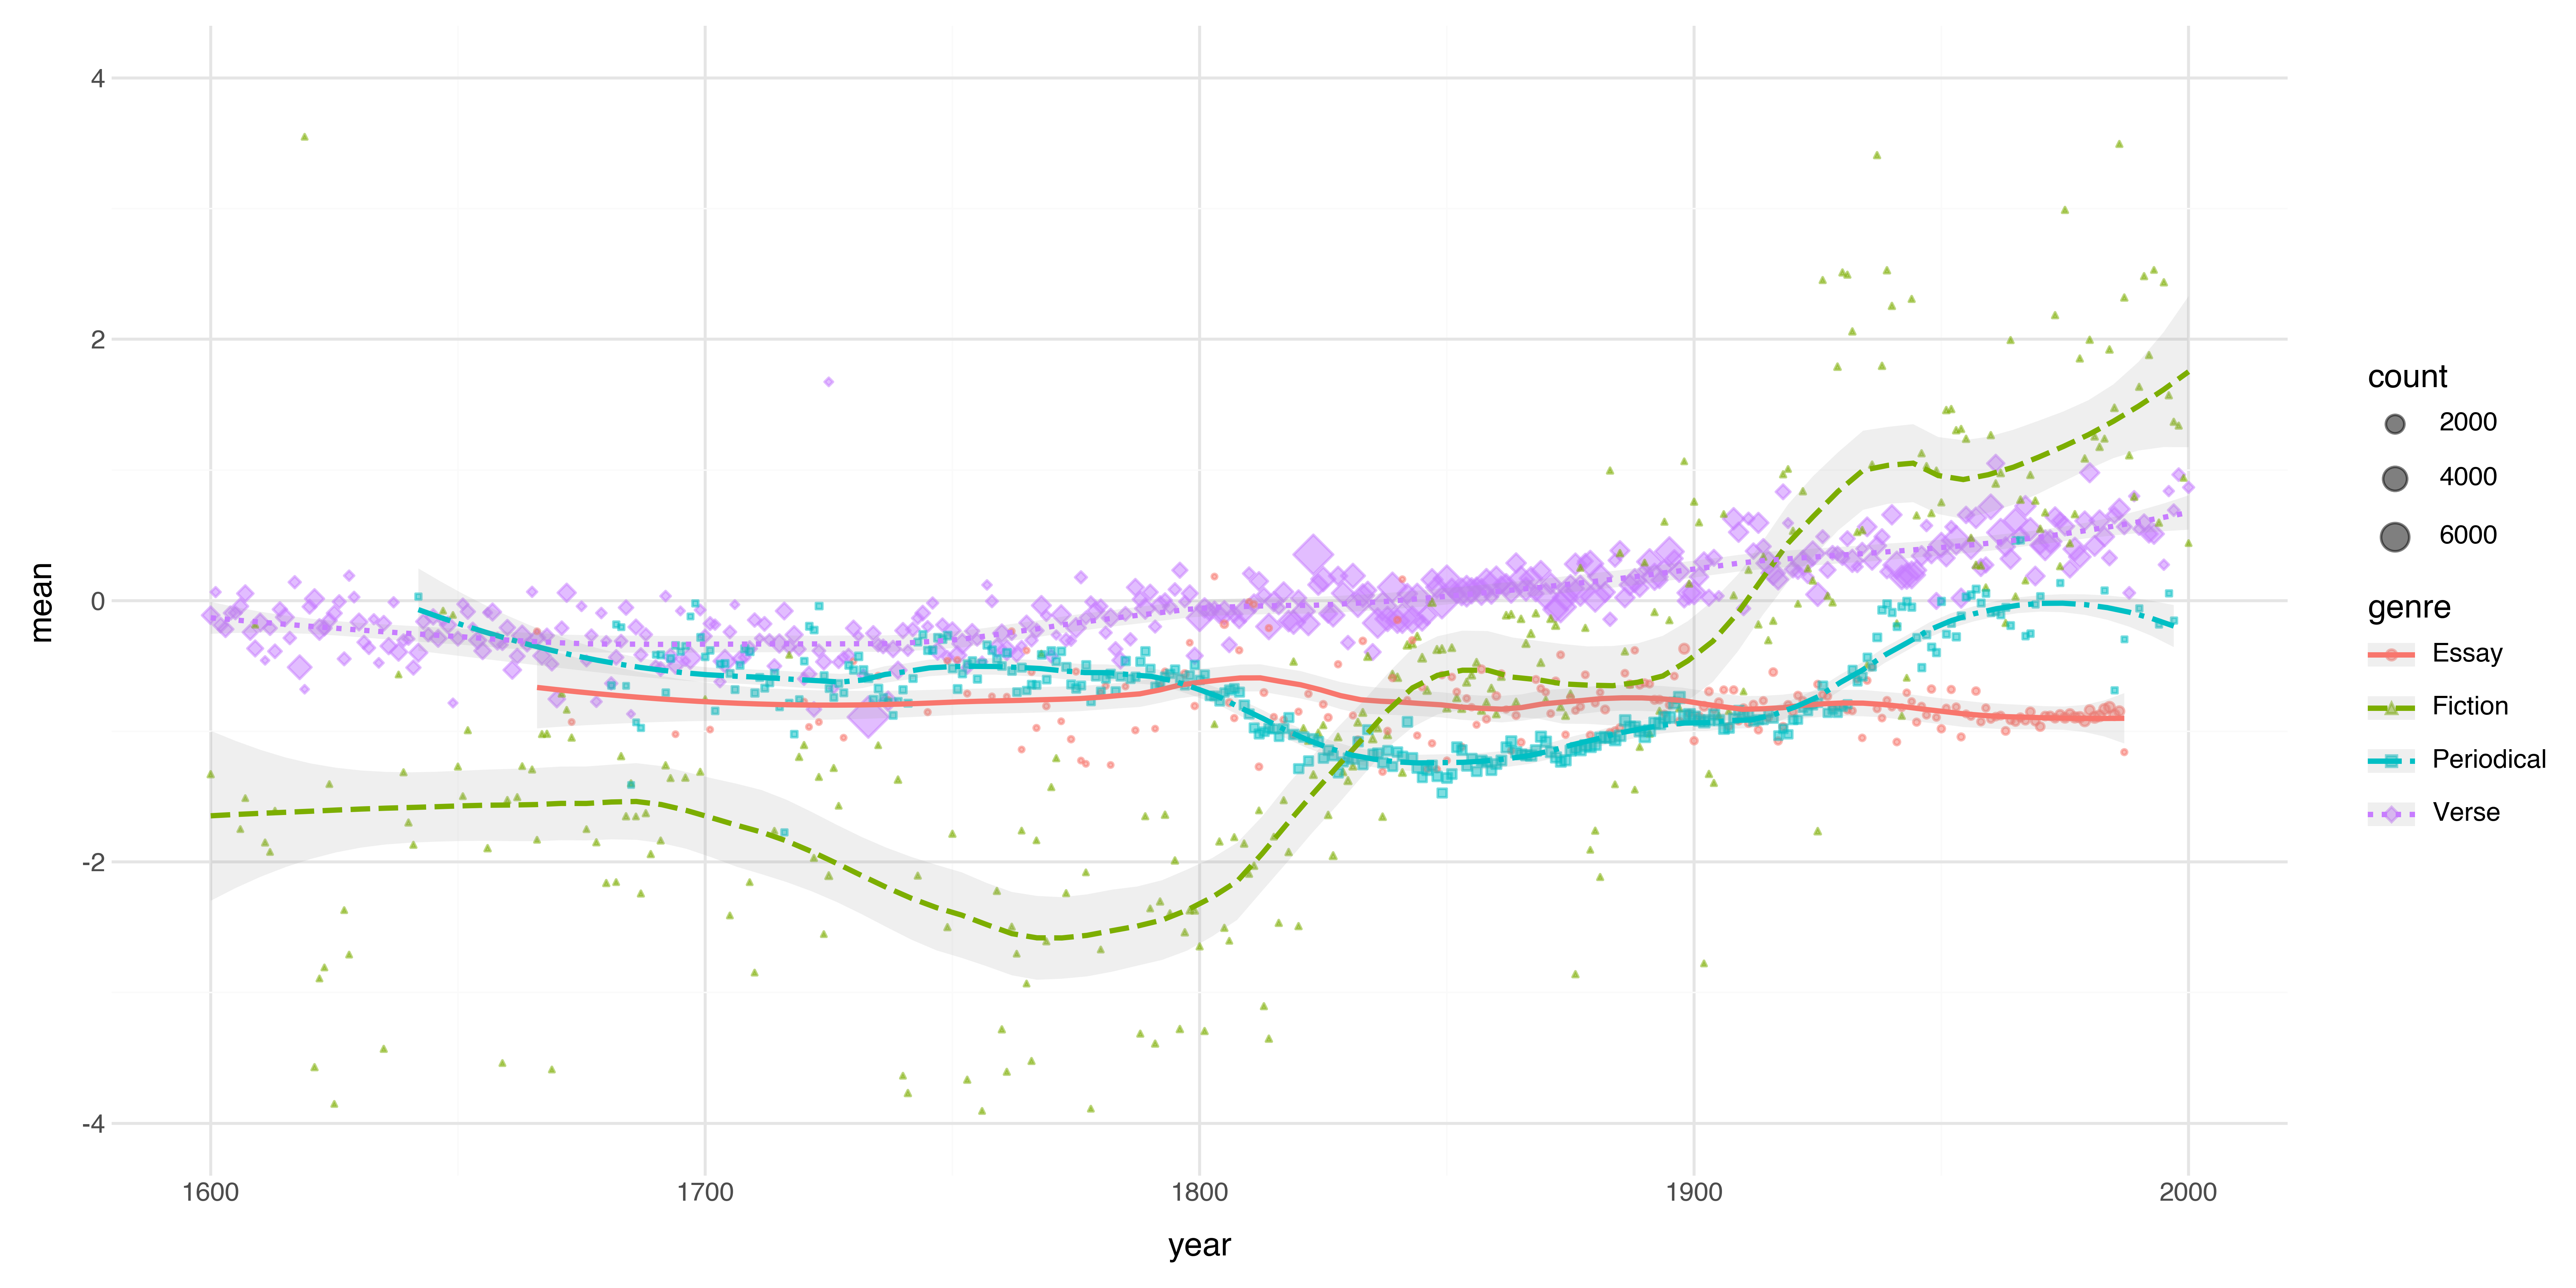

In [132]:
figdf = odf.reset_index().query(f'1600<={yearcol}<=2000')
# figdf = figdf[figdf.genre.isin(genres)]

plot_avgs_df(figdf)